Dataset Loaded: 1025 Pokemon
Training on 39 features to find anomalies.
Tuning Isolation Forest parameters...
Best Parameters: {'anomaly_detector__contamination': 0.07, 'anomaly_detector__n_estimators': 100}

Detection Results:
anomaly_label
Balanced (1)         953
Balance Risk (-1)     72
Name: count, dtype: int64


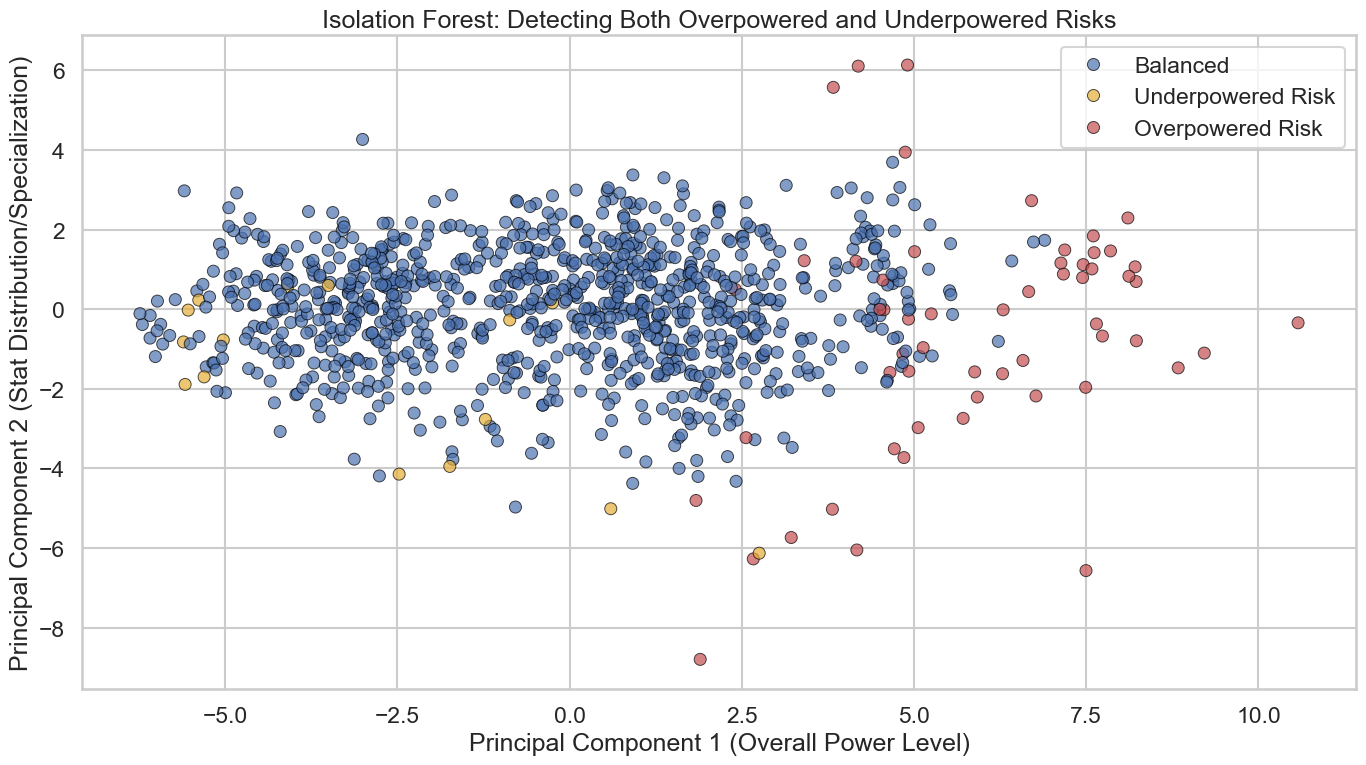


--- Top 5 OVERPOWERED Balance Risks (High Stat Anomalies) ---


,pokedex_id,base_stat_total,speed,offensive_total,raw_risk_score
889,890,690,2.188384,360,-0.101306
212,213,505,-2.166529,25,-0.088528
804,805,570,-1.887814,197,-0.085635
241,242,540,-0.424564,140,-0.071969
798,799,570,-0.842635,241,-0.045549



--- Top 5 UNDERPOWERED Design Risks (Low Stat Anomalies) ---


,pokedex_id,base_stat_total,hp,speed,raw_risk_score
112,113,450,6.755399,-0.598760,-0.064198
789,790,400,-1.021276,-1.051671,-0.063733
94,95,385,-1.321824,0.098026,-0.026398
788,789,200,-1.021276,-1.051671,-0.022627
439,440,220,1.120127,-1.295546,-0.022241



Simulation: Extreme Speed Glass Cannon
Status: ⚠️ HIGH BALANCE RISK | Raw Anomaly Score: -0.061

Unsupervised Sentinel pipeline saved successfully for deployment.


In [8]:
# %% [markdown]
# # The Anomaly Sentinel: Unsupervised Balance Risk Detection
# This notebook uses an Isolation Forest (Unsupervised Learning) to identify 
# Pokémon designs that are statistical anomalies, representing potential "Balance Risks" 
# to Game Developers without relying on hard-coded stat thresholds.

# %% [code]
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from joblib import dump

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.decomposition import PCA
import numpy as np

# Formatting for presentation
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)

# %% [code]
# 1. Data Loading
data_path = Path("../data/final_processed_dataset.csv")
df = pd.read_csv(data_path)

print(f"Dataset Loaded: {df.shape[0]} Pokemon")

# %% [code]
# 2. Feature Selection
# We drop the ID. We KEEP base_stat_total and offensive_total here because in unsupervised 
# learning, we aren't using them as labels to cheat; they are just more data points for the 
# model to figure out what is "normal" vs "weird".
X = df.drop(columns=["pokedex_id"])

print(f"Training on {X.shape[1]} features to find anomalies.")

# %% [code]
# 3. Hyperparameter Tuning (GridSearchCV for Isolation Forest)
# We tune 'contamination' (expected % of anomalies) and 'n_estimators'.
# Note: Scoring unsupervised models is tricky. We'll use a custom scorer that rewards 
# finding distinct anomalies (lower average anomaly score for the worst 5%).

def custom_anomaly_scorer(estimator, X):
    scores = estimator.decision_function(X)
    # Return the negative mean of the lowest 5% scores (we want this to be as low/negative as possible)
    return -np.mean(np.sort(scores)[:int(len(scores)*0.05)])

sentinel_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('anomaly_detector', IsolationForest(random_state=42, n_jobs=-1))
])

param_grid = {
    'anomaly_detector__contamination': [0.03, 0.05, 0.07],
    'anomaly_detector__n_estimators': [100, 200, 300]
}

print("Tuning Isolation Forest parameters...")
grid_search = GridSearchCV(
    sentinel_pipeline, 
    param_grid, 
    cv=5, 
    scoring=custom_anomaly_scorer
)
grid_search.fit(X)

best_sentinel = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# %% [code]
# 4. Generating the Risk Scores
# -1 means Anomaly (Risk), 1 means Normal (Balanced)
df['anomaly_label'] = best_sentinel.predict(X)

# Raw anomaly score (lower means MORE anomalous)
df['raw_risk_score'] = best_sentinel.decision_function(X)

print("\nDetection Results:")
print(df['anomaly_label'].value_counts().rename({1: 'Balanced (1)', -1: 'Balance Risk (-1)'}))

# %% [code]
# 5. Categorizing Anomalies (Overpowered vs. Underpowered)
median_bst = df['base_stat_total'].median()

def categorize_anomaly(row):
    if row['anomaly_label'] == 1:
        return 'Balanced'
    elif row['base_stat_total'] > median_bst:
        return 'Overpowered Risk'
    else:
        return 'Underpowered Risk'

df['risk_category'] = df.apply(categorize_anomaly, axis=1)

# %% [code]
# 6. Presentation Visualization: PCA Anomaly Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df, x='PCA1', y='PCA2', 
    hue='risk_category', 
    palette={'Balanced': '#4C72B0', 'Overpowered Risk': '#C44E52', 'Underpowered Risk': '#E6AE38'},
    alpha=0.7, s=75, edgecolor='black'
)

plt.title("Isolation Forest: Detecting Both Overpowered and Underpowered Risks")
plt.xlabel("Principal Component 1 (Overall Power Level)")
plt.ylabel("Principal Component 2 (Stat Distribution/Specialization)")
plt.legend()
plt.tight_layout()
plt.show()

# %% [code]
# 7. Deep Dive: Who are the Anomalies?
anomalies = df[df['anomaly_label'] == -1]
overpowered = anomalies[anomalies['risk_category'] == 'Overpowered Risk'].sort_values(by='raw_risk_score')
underpowered = anomalies[anomalies['risk_category'] == 'Underpowered Risk'].sort_values(by='raw_risk_score')

print("\n--- Top 5 OVERPOWERED Balance Risks (High Stat Anomalies) ---")
display(overpowered[['pokedex_id', 'base_stat_total', 'speed', 'offensive_total', 'raw_risk_score']].head(5))

print("\n--- Top 5 UNDERPOWERED Design Risks (Low Stat Anomalies) ---")
display(underpowered[['pokedex_id', 'base_stat_total', 'hp', 'speed', 'raw_risk_score']].head(5))

# %% [code]
# 8. Developer Simulation Tool (Interactive)
def check_new_design_risk(hp, attack, defense, sp_atk, sp_def, speed, bst, off_total):
    # Dummy creation of a full feature row (filling other columns with 0)
    input_data = pd.DataFrame([[0]*len(X.columns)], columns=X.columns)
    input_data['hp'] = hp
    input_data['attack'] = attack
    input_data['defense'] = defense
    input_data['sp_attack'] = sp_atk
    input_data['sp_defense'] = sp_def
    input_data['speed'] = speed
    input_data['base_stat_total'] = bst
    input_data['offensive_total'] = off_total
    
    # Predict (-1 is risk, 1 is safe)
    prediction = best_sentinel.predict(input_data)[0]
    score = best_sentinel.decision_function(input_data)[0]
    
    status = "⚠️ HIGH BALANCE RISK" if prediction == -1 else "✅ BALANCED DESIGN"
    return f"Status: {status} | Raw Anomaly Score: {score:.3f}"

# Test Simulation
print("\nSimulation: Extreme Speed Glass Cannon")
print(check_new_design_risk(hp=50, attack=150, defense=50, sp_atk=150, sp_def=50, speed=150, bst=600, off_total=300))

# %% [code]
# 9. Export for Member 6 (Deployment)
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

dump(best_sentinel, models_dir / "unsupervised_balance_risk_pipeline.joblib")
print("\nUnsupervised Sentinel pipeline saved successfully for deployment.")

In [7]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Load processed data for modeling
df_processed = pd.read_csv("../data/final_processed_dataset.csv")
X = df_processed.drop(columns=["pokedex_id"])

# Load raw data for names and readable stats
df_raw = pd.read_csv("../data/pokemon_complete_2025.csv")

# Build and fit the Sentinel
sentinel_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('anomaly_detector', IsolationForest(contamination=0.05, random_state=42, n_jobs=-1))
])

sentinel_pipeline.fit(X)

# Get scores
df_raw['anomaly_label'] = sentinel_pipeline.predict(X)
df_raw['raw_risk_score'] = sentinel_pipeline.decision_function(X)

# Median BST for categorization
median_bst = df_raw['base_stat_total'].median()

# Filter and sort
anomalies = df_raw[df_raw['anomaly_label'] == -1].copy()
overpowered = anomalies[anomalies['base_stat_total'] > median_bst].sort_values(by='raw_risk_score')

# Select top 10
top_10_op = overpowered[['pokedex_id', 'name', 'base_stat_total', 'attack', 'sp_attack', 'speed', 'raw_risk_score']].head(10)
print(top_10_op.to_string())

     pokedex_id              name  base_stat_total  attack  sp_attack  speed  raw_risk_score
889         890         eternatus              690      85        145    130       -0.094861
212         213           shuckle              505      10         10      5       -0.082083
804         805         stakataka              570     131         53     13       -0.079190
241         242           blissey              540      10         75     55       -0.065523
798         799          guzzlord              570     101         97     43       -0.039103
486         487  giratina-altered              680     100        100     90       -0.038937
207         208           steelix              510      85         55     30       -0.033064
483         484            palkia              680     120        150    100       -0.030769
375         376         metagross              600     135         95     70       -0.027292
895         896         glastrier              580     145         65 